# Underwater Segmentation: Kaggle Experiments

Этот notebook предназначен для запуска экспериментов в Kaggle: проверка данных, обучение U-Net baseline, обучение DeepLabV3 ResNet50 baseline, сохранение чекпоинтов, метрик, визуализаций и архива с результатами.

## Где менять путь к датасету

Канонический Kaggle путь для SUIM dataset:

```python
DATA_DIR = /kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim
```

Если dataset подключён под другим именем, поменяйте `DATASET_NAME` или задайте `DATA_DIR` напрямую в ячейке **Configuration**. Код сначала ищет `train/images` и `train/masks`, а если их нет — использует реальную структуру SUIM `train_val/images` и `train_val/masks`. Для теста используется `test/images`, иначе `TEST/images`.

Notebook не использует локальные приватные пути и не требует GPU: если CUDA недоступна, код запустится на CPU, но обучение будет медленнее.

## 1. Clone or Use Repository Code

Если notebook запущен из репозитория и рядом есть папка `src`, используется текущий код. Если нет, репозиторий клонируется в `/kaggle/working/Underwater_segmentation`.

In [31]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = os.environ.get(
    "REPO_URL",
    "https://github.com/MataNerdy/Underwater_segmentation.git"
)

REPO_DIR = Path("/kaggle/working/Underwater_segmentation")
BRANCH = os.environ.get("BRANCH", "main")

if REPO_DIR.exists():
    print("Repo already exists. Pulling latest changes...")
    os.chdir(REPO_DIR)
    subprocess.run(["git", "fetch", "origin"], check=True)
    subprocess.run(["git", "checkout", BRANCH], check=True)
    subprocess.run(["git", "pull", "origin", BRANCH], check=True)
else:
    print("Cloning repo...")
    subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)

PROJECT_DIR = REPO_DIR
sys.path.insert(0, str(PROJECT_DIR))

print(f"Using project directory: {PROJECT_DIR}")

subprocess.run(["git", "status"], check=True)
subprocess.run(["git", "log", "--oneline", "-3"], check=True)

Repo already exists. Pulling latest changes...


From https://github.com/MataNerdy/Underwater_segmentation
   490e7af..6a02cca  main       -> origin/main
Already on 'main'


Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating 490e7af..6a02cca
Fast-forward
 scripts/run_kaggle_experiments.sh | 7 ++++---
 1 file changed, 4 insertions(+), 3 deletions(-)
Using project directory: /kaggle/working/Underwater_segmentation
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
6a02cca new script
490e7af new script
d41d4fd Merge pull request #7 from MataNerdy/codex/add-deeplabv3-option


From https://github.com/MataNerdy/Underwater_segmentation
 * branch            main       -> FETCH_HEAD


CompletedProcess(args=['git', 'log', '--oneline', '-3'], returncode=0)

## 2. Install Requirements If Needed

In [32]:
required_imports = ["torch", "torchvision", "numpy", "PIL", "matplotlib", "tqdm"]
missing = []

for package_name in required_imports:
    try:
        __import__(package_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Missing packages:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    print("All required packages are already available.")

All required packages are already available.


## 3. Configuration

По умолчанию используется Kaggle dataset `datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim`. Если в вашем Kaggle notebook путь отличается, измените `DATASET_NAME` или задайте `DATA_DIR` напрямую.

Реальная структура данных:

```text
/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/
├── train_val/images
├── train_val/masks
└── TEST/images
```

In [33]:
from pathlib import Path
import torch

DATASET_NAME = os.environ.get("DATASET_NAME", "datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim")
DATA_DIR = Path(os.environ.get("DATA_DIR", f"/kaggle/input/{DATASET_NAME}"))

def select_existing_dir(label, *candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            print(f"Selected {label}: {candidate}")
            return candidate
    fallback = Path(candidates[-1])
    print(f"Selected {label}: {fallback} (not found yet)")
    return fallback

TRAIN_IMAGES_DIR = select_existing_dir("train images dir", DATA_DIR / "train" / "images", DATA_DIR / "train_val" / "images")
TRAIN_MASKS_DIR = select_existing_dir("train masks dir", DATA_DIR / "train" / "masks", DATA_DIR / "train_val" / "masks")
TEST_IMAGES_DIR = select_existing_dir("test images dir", DATA_DIR / "test" / "images", DATA_DIR / "TEST" / "images")

WORKING_DIR = Path("/kaggle/working")
CHECKPOINT_DIR = WORKING_DIR / "checkpoints"
EXPERIMENTS_DIR = WORKING_DIR / "experiments"
ASSETS_DIR = WORKING_DIR / "assets"

for directory in [CHECKPOINT_DIR, EXPERIMENTS_DIR, ASSETS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DATA_DIR: {DATA_DIR}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available. Training will run on CPU.")

DATA_DIR: /kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim
Device: cuda
GPU: Tesla T4


## 4. Sanity Checks: Files, Image and Mask

/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images exists= True
  files: 1525
  first: ['d_r_103_.jpg', 'd_r_105_.jpg', 'd_r_112_.jpg', 'd_r_113_.jpg', 'd_r_125_.jpg']
/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks exists= True
  files: 1525
  first: ['d_r_103_.bmp', 'd_r_105_.bmp', 'd_r_112_.bmp', 'd_r_113_.bmp', 'd_r_125_.bmp']
/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/TEST/images exists= True
  files: 110
  first: ['d_r_122_.jpg', 'd_r_129_.jpg', 'd_r_144_.jpg', 'd_r_166_.jpg', 'd_r_182_.jpg']


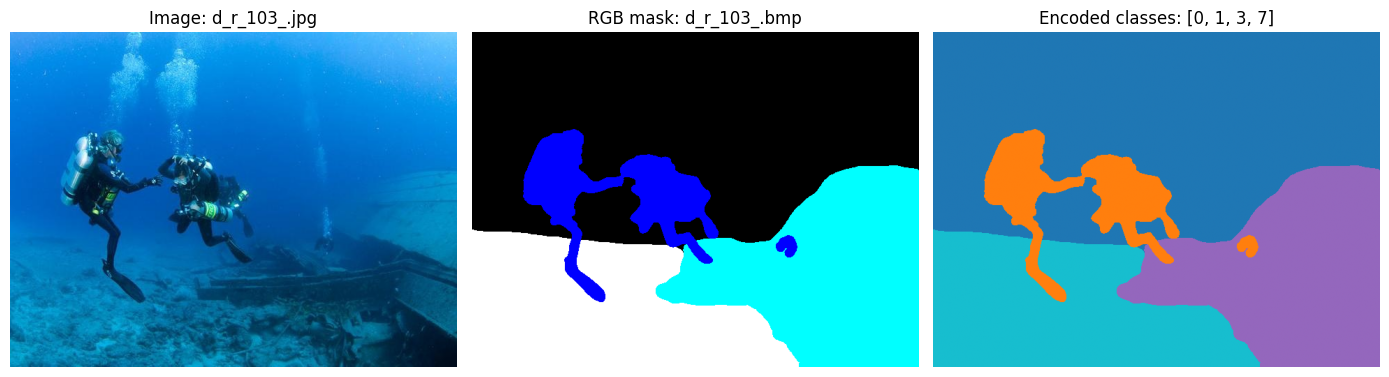

In [34]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import IMAGE_EXTENSIONS, rgb_mask_to_index

for path in [TRAIN_IMAGES_DIR, TRAIN_MASKS_DIR, TEST_IMAGES_DIR]:
    print(path, "exists=", path.exists())
    if path.exists():
        files = sorted(p for p in path.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
        print("  files:", len(files))
        print("  first:", [p.name for p in files[:5]])

train_images = sorted(p for p in TRAIN_IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
train_masks = sorted(p for p in TRAIN_MASKS_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
assert train_images, f"No train images found in {TRAIN_IMAGES_DIR}"
assert train_masks, f"No train masks found in {TRAIN_MASKS_DIR}"

image_path = train_images[0]
mask_candidates = [p for p in train_masks if p.stem == image_path.stem]
assert mask_candidates, f"No matching mask found for {image_path.name}"
mask_path = mask_candidates[0]

image = Image.open(image_path).convert("RGB")
mask_rgb = Image.open(mask_path).convert("RGB")
mask_idx = rgb_mask_to_index(mask_rgb)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image)
axes[0].set_title(f"Image: {image_path.name}")
axes[1].imshow(mask_rgb)
axes[1].set_title(f"RGB mask: {mask_path.name}")
axes[2].imshow(mask_idx, vmin=0, vmax=7, cmap="tab10")
axes[2].set_title(f"Encoded classes: {np.unique(mask_idx).tolist()}")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 5. Experiment Settings

Для быстрого smoke run можно оставить `EPOCHS = 1`. Для полноценного сравнения увеличьте `EPOCHS`, например до `10` или `20`.

In [35]:
EPOCHS = int(os.environ.get("EPOCHS", "1"))
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "8"))
IMAGE_SIZE = int(os.environ.get("IMAGE_SIZE", "256"))
LR = float(os.environ.get("LR", "1e-4"))
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "2"))

print({
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "lr": LR,
    "num_workers": NUM_WORKERS,
})

{'epochs': 1, 'batch_size': 8, 'image_size': 256, 'lr': 0.0001, 'num_workers': 2}


## 6. Train U-Net Baseline

Чекпоинт будет сохранён в `/kaggle/working/checkpoints/unet/best.pth`, результаты — в `/kaggle/working/experiments/results.csv`.

In [36]:
unet_checkpoint_dir = CHECKPOINT_DIR / "unet"
unet_checkpoint_dir.mkdir(parents=True, exist_ok=True)

!python src/train.py \
  --model unet \
  --images-dir "{TRAIN_IMAGES_DIR}" \
  --masks-dir "{TRAIN_MASKS_DIR}" \
  --checkpoint-dir "{unet_checkpoint_dir}" \
  --results-csv "{EXPERIMENTS_DIR / 'results.csv'}" \
  --assets-dir "{ASSETS_DIR}" \
  --experiment-name unet_kaggle_baseline \
  --epochs {EPOCHS} \
  --batch-size {BATCH_SIZE} \
  --image-size {IMAGE_SIZE} \
  --lr {LR} \
  --num-workers {NUM_WORKERS} \
  --device {DEVICE}

UNET_CHECKPOINT = unet_checkpoint_dir / "best.pth"
print("U-Net checkpoint:", UNET_CHECKPOINT)

epoch=001 train_loss=1.7470 val_loss=1.5075 val_miou=0.1745 val_acc=0.5668      
U-Net checkpoint: /kaggle/working/checkpoints/unet/best.pth


## 7. Train DeepLabV3 ResNet50 Baseline

По умолчанию `USE_PRETRAINED_BACKBONE = False`, чтобы notebook не требовал скачивания весов. Если интернет в Kaggle включён и нужны pretrained weights, поставьте `True`.

In [37]:
USE_PRETRAINED_BACKBONE = os.environ.get("USE_PRETRAINED_BACKBONE", "0") == "1"
deeplab_checkpoint_dir = CHECKPOINT_DIR / "deeplabv3_resnet50"
deeplab_checkpoint_dir.mkdir(parents=True, exist_ok=True)
pretrained_flag = "--pretrained-backbone" if USE_PRETRAINED_BACKBONE else ""

!python src/train.py \
  --model deeplabv3_resnet50 \
  {pretrained_flag} \
  --images-dir "{TRAIN_IMAGES_DIR}" \
  --masks-dir "{TRAIN_MASKS_DIR}" \
  --checkpoint-dir "{deeplab_checkpoint_dir}" \
  --results-csv "{EXPERIMENTS_DIR / 'results.csv'}" \
  --assets-dir "{ASSETS_DIR}" \
  --experiment-name deeplabv3_resnet50_kaggle_baseline \
  --epochs {EPOCHS} \
  --batch-size {BATCH_SIZE} \
  --image-size {IMAGE_SIZE} \
  --lr {LR} \
  --num-workers {NUM_WORKERS} \
  --device {DEVICE}

DEEPLAB_CHECKPOINT = deeplab_checkpoint_dir / "best.pth"
print("DeepLabV3 checkpoint:", DEEPLAB_CHECKPOINT)

epoch=001 train_loss=1.3334 val_loss=1.1433 val_miou=0.2026 val_acc=0.6291      
DeepLabV3 checkpoint: /kaggle/working/checkpoints/deeplabv3_resnet50/best.pth


In [38]:
import os
print(os.listdir(DATA_DIR))

['TEST', 'train_val']


In [42]:
import os

os.environ["TRAIN_IMAGES_DIR"] = "/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images"

os.environ["TRAIN_MASKS_DIR"] = "/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks"

In [44]:
from pathlib import Path

images_dir = Path("/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images")
masks_dir = Path("/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks")

print(len(list(images_dir.glob("*"))))
print(len(list(masks_dir.glob("*"))))

print(next(images_dir.iterdir()))
print(next(masks_dir.iterdir()))

1525
1525
/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/n_l_8_.jpg
/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/d_r_52_.bmp


In [45]:
!chmod +x scripts/run_kaggle_experiments.sh
!./scripts/run_kaggle_experiments.sh

DATA_DIR=/kaggle/input/semantic-segmentation-of-underwater-imagery-suim
WORKING_DIR=/kaggle/working
EPOCHS=20
DEVICE=cuda
RESULTS_CSV=/kaggle/working/experiments/results.csv
Running unet_size128_main
epoch=001 train_loss=1.7311 val_loss=1.4832 val_miou=0.1734 val_acc=0.5800      
epoch=002 train_loss=1.5114 val_loss=1.3808 val_miou=0.1875 val_acc=0.6174      
epoch=003 train_loss=1.4117 val_loss=1.3154 val_miou=0.1974 val_acc=0.6302      
epoch=004 train_loss=1.3472 val_loss=1.2714 val_miou=0.1957 val_acc=0.6318      
epoch=005 train_loss=1.2945 val_loss=1.2436 val_miou=0.1983 val_acc=0.6359      
epoch=006 train_loss=1.2474 val_loss=1.2107 val_miou=0.2075 val_acc=0.6467      
epoch=007 train_loss=1.2122 val_loss=1.1287 val_miou=0.2120 val_acc=0.6560      
epoch=008 train_loss=1.1788 val_loss=1.1818 val_miou=0.2247 val_acc=0.6434      
epoch=009 train_loss=1.1425 val_loss=1.0984 val_miou=0.2237 val_acc=0.6556      
epoch=010 train_loss=1.1230 val_loss=1.0693 val_miou=0.2260 val_acc=0.6

## 8. Inspect Experiment Results

In [46]:
results_path = EXPERIMENTS_DIR / "results.csv"

try:
    import pandas as pd
    display(pd.read_csv(results_path))
except ImportError:
    print(results_path.read_text())

,experiment,model,lr,batch_size,image_size,epochs,weighted_loss,pretrained_backbone,features,best_val_miou,best_val_pixel_accuracy,checkpoint,best_val_iou_class_0,best_val_iou_class_1,best_val_iou_class_2,best_val_iou_class_3,best_val_iou_class_4,best_val_iou_class_5,best_val_iou_class_6,best_val_iou_class_7
0,unet_kaggle_baseline,unet,0.0001,8,256,1,False,False,32,0.166624,0.576866,/kaggle/working/checkpoints/unet/best.pth,0.572956,0.008755,0.019001,0.030841,0.008628,0.519855,0.001406,0.171547
1,deeplabv3_resnet50_kaggle_baseline,deeplabv3_resnet50,0.0001,8,256,1,False,False,32,0.168937,0.606147,/kaggle/working/checkpoints/deeplabv3_resnet50...,0.601306,0.000000,0.000000,0.049991,0.000000,0.535940,0.023274,0.140989
2,unet_kaggle_baseline,unet,0.0001,8,256,1,False,False,32,0.171152,0.586369,/kaggle/working/checkpoints/unet/best.pth,0.567028,0.001040,0.000037,0.056966,0.000995,0.529923,0.003972,0.209254
3,unet_kaggle_baseline,unet,0.0001,8,256,1,False,False,32,0.174545,0.566806,/kaggle/working/checkpoints/unet/best.pth,0.587063,0.000880,0.004892,0.100236,0.000447,0.522991,0.000066,0.179782
4,deeplabv3_resnet50_kaggle_baseline,deeplabv3_resnet50,0.0001,8,256,1,False,False,32,0.202602,0.629103,/kaggle/working/checkpoints/deeplabv3_resnet50...,0.626734,0.001581,0.000000,0.122956,0.000000,0.550730,0.040748,0.278072
5,unet_size128_main,unet,0.0001,16,128,20,False,False,32,0.297318,0.698849,/kaggle/working/checkpoints/unet_size128_main/...,0.771610,0.177952,0.000000,0.239843,0.000000,0.607017,0.198496,0.383622
6,unet_size256_main,unet,0.0001,16,256,20,False,False,32,0.252723,0.678170,/kaggle/working/checkpoints/unet_size256_main/...,0.723594,0.000000,0.000000,0.142274,0.000000,0.591369,0.225134,0.339409
7,unet_weighted_ce_size256_main,unet,0.0001,16,256,20,True,False,32,0.276628,0.553481,/kaggle/working/checkpoints/unet_weighted_ce_s...,0.702942,0.184823,0.077282,0.185869,0.115001,0.403196,0.228871,0.315044
8,deeplabv3_resnet50_size256_main,deeplabv3_resnet50,0.0001,16,256,20,False,False,32,0.389566,0.725624,/kaggle/working/checkpoints/deeplabv3_resnet50...,0.760284,0.387789,0.091826,0.437507,0.136370,0.619201,0.275594,0.407955
9,deeplabv3_resnet50_pretrained_size256_main,deeplabv3_resnet50,0.0001,16,256,20,False,True,32,0.634414,0.822570,/kaggle/working/checkpoints/deeplabv3_resnet50...,0.846060,0.741310,0.202565,0.706464,0.724594,0.715305,0.634939,0.504080


## 9. Save Prediction Visualization Examples

Визуализация ниже использует U-Net checkpoint. При желании замените `UNET_CHECKPOINT` на `DEEPLAB_CHECKPOINT`.

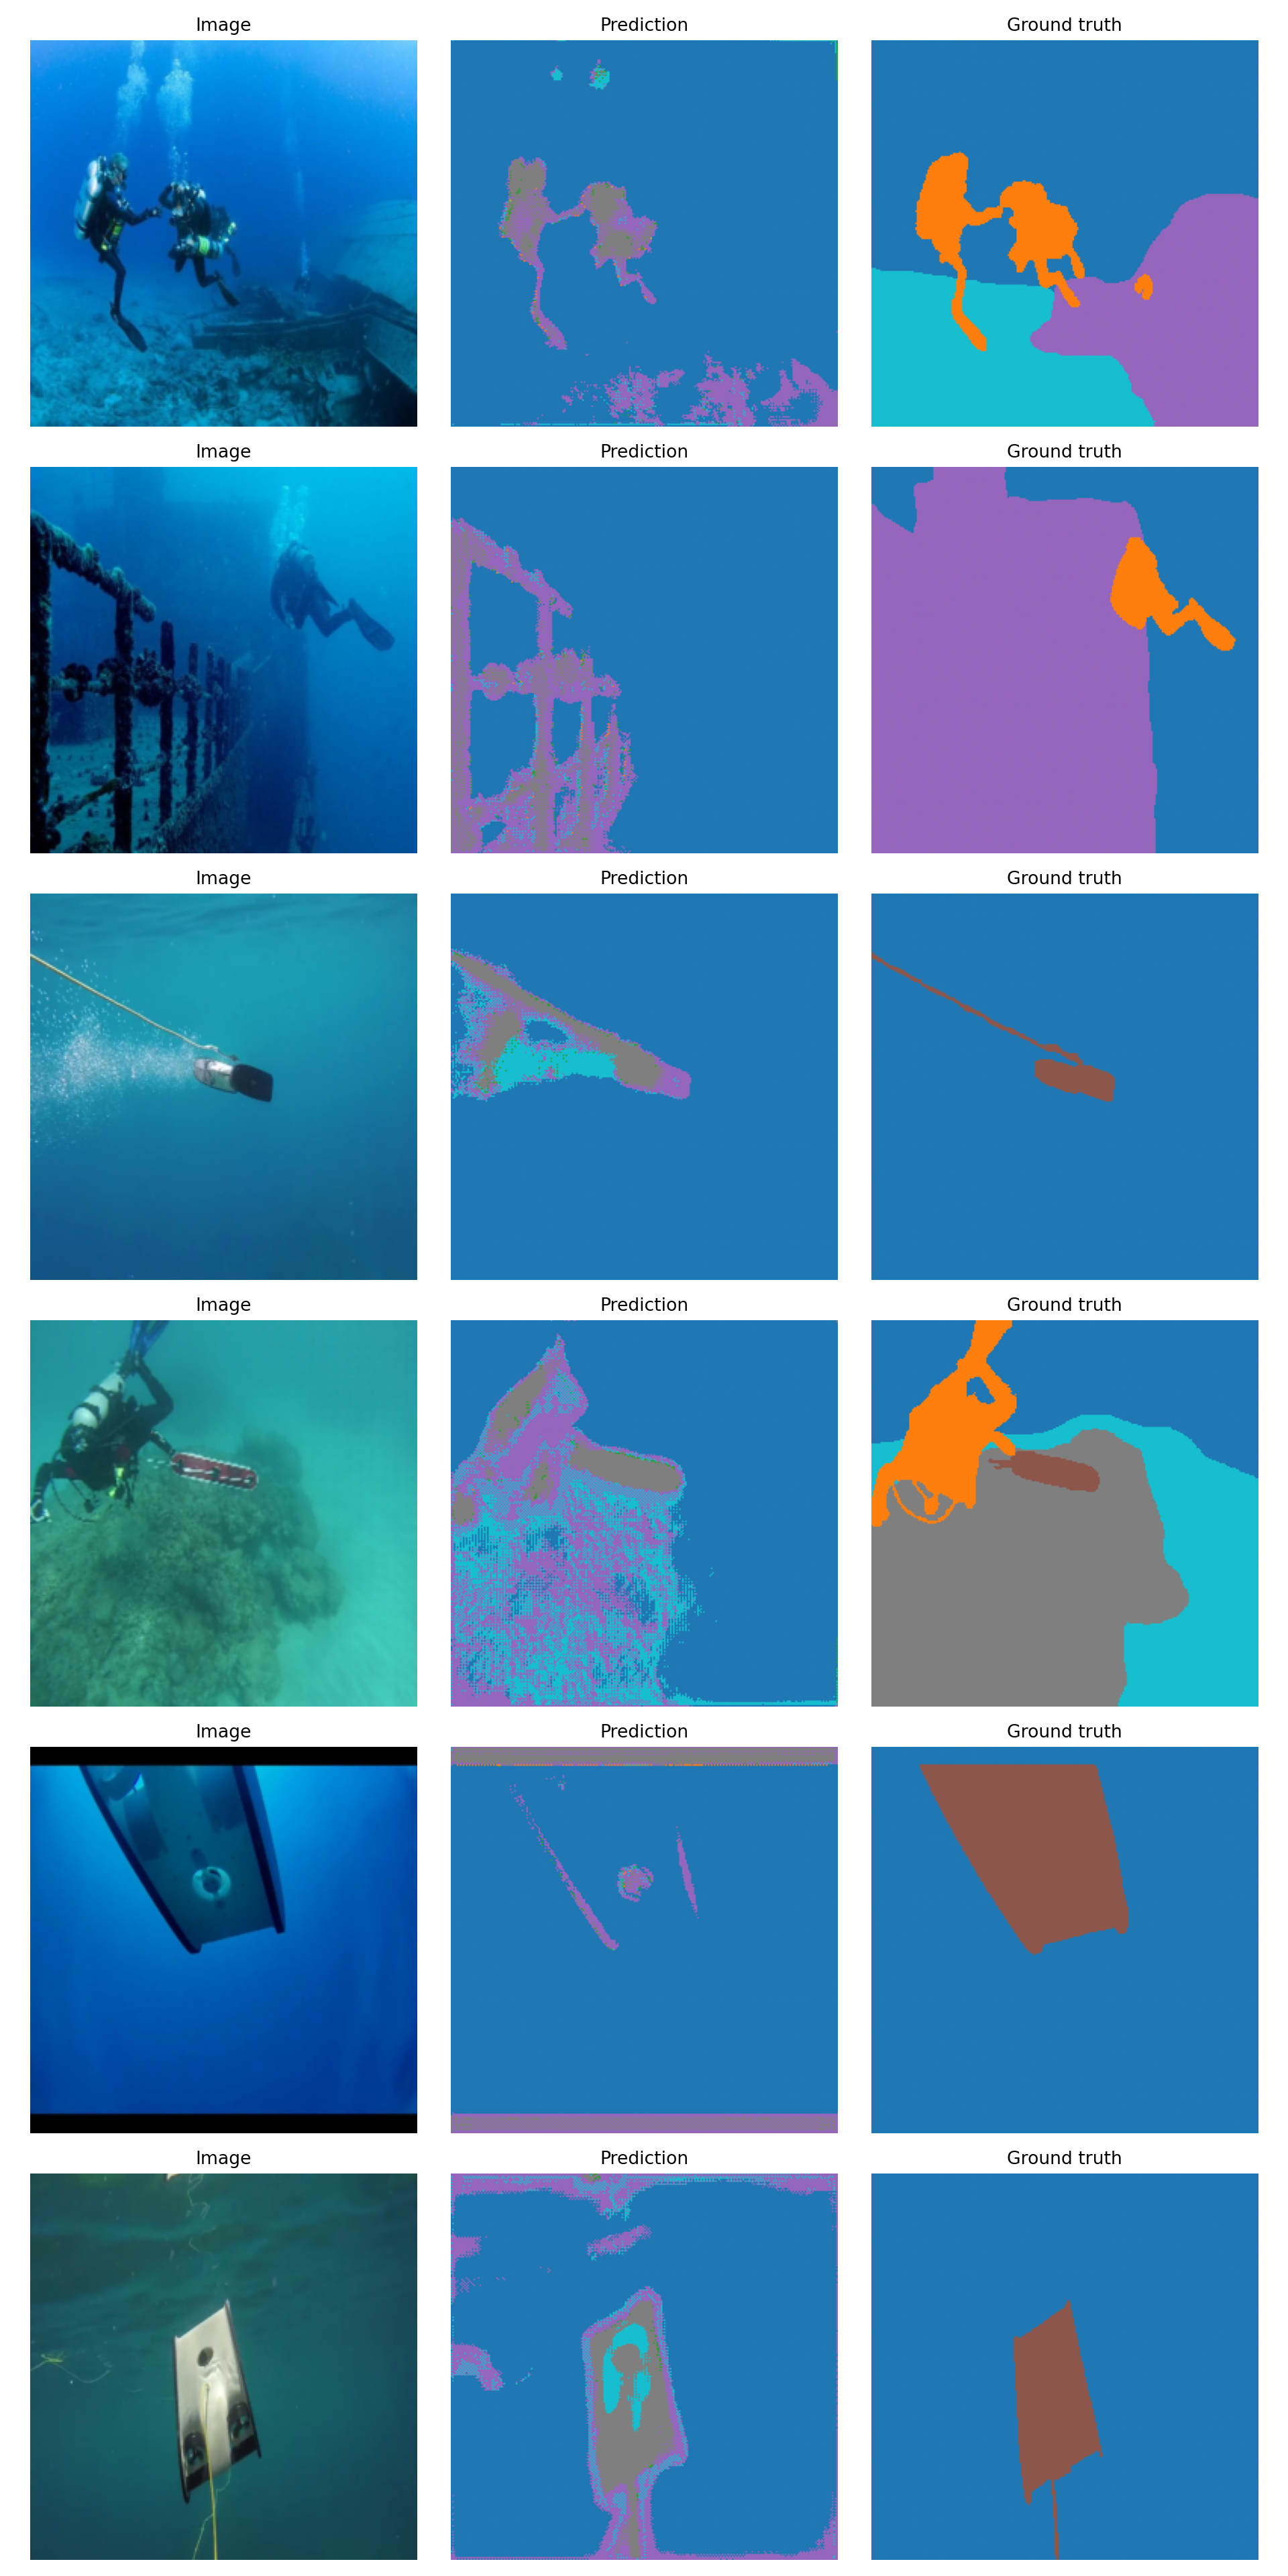

In [47]:
!python src/visualize.py \
  --images-dir "{TRAIN_IMAGES_DIR}" \
  --masks-dir "{TRAIN_MASKS_DIR}" \
  --checkpoint "{UNET_CHECKPOINT}" \
  --output "{ASSETS_DIR / 'prediction_examples.png'}" \
  --num-examples 6 \
  --device {DEVICE}

from IPython.display import Image as IPyImage, display
prediction_examples = ASSETS_DIR / "prediction_examples.png"
display(IPyImage(filename=str(prediction_examples)))

## 10. Optional: Generate Test Submission with Horizontal Flip TTA

Эта ячейка создаёт `/kaggle/working/submission.txt`, если есть `test/images`.

In [48]:
if TEST_IMAGES_DIR.exists():
    !python src/predict.py \
      --images-dir "{TEST_IMAGES_DIR}" \
      --checkpoint "{UNET_CHECKPOINT}" \
      --output "{WORKING_DIR / 'submission.txt'}" \
      --predictions-dir "{WORKING_DIR / 'predictions'}" \
      --tta \
      --device {DEVICE}
else:
    print(f"Skipping prediction: {TEST_IMAGES_DIR} does not exist")

predict: 100%|████████████████████████████████████| 2/2 [00:02<00:00,  1.45s/it]
/kaggle/working/Underwater_segmentation/src/predict.py:201: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(mask, mode="L").save(args.predictions_dir / f"{image_id}.png")


## 11. Zip Outputs

Архив будет сохранён как `/kaggle/working/underwater_experiments_outputs.zip`.

In [49]:
import zipfile

zip_path = WORKING_DIR / "underwater_experiments_outputs.zip"
paths_to_zip = [CHECKPOINT_DIR, EXPERIMENTS_DIR, ASSETS_DIR, WORKING_DIR / "submission.txt", WORKING_DIR / "predictions"]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in paths_to_zip:
        if not path.exists():
            continue
        if path.is_file():
            archive.write(path, arcname=path.relative_to(WORKING_DIR))
        else:
            for file_path in path.rglob("*"):
                if file_path.is_file():
                    archive.write(file_path, arcname=file_path.relative_to(WORKING_DIR))

print(f"Saved: {zip_path}")

Saved: /kaggle/working/underwater_experiments_outputs.zip
